# 06 — Logit Básico (statsmodels)

**Modelo econométrico base.** Regresión logística sin regularización estimada por MLE.
Ventaja principal: coeficientes interpretables con p-values, errores estándar y desvíos.

Referencia de clase: `modelos R/logit/0 - Modelos lineales generalizados (glm).R`

**Flujo:**
1. Carga de `features_train.parquet` (30 features, 307k filas)
2. Imputación mediana + estandarización
3. 5-fold CV AUC (sklearn, modelo equivalente)
4. Modelo final con `statsmodels.Logit` → summary exportable a LaTeX
5. Métricas: AUC, N, P, TP, TN, FP, FN, Recall, Precision, F1
6. ROC curve + coeficientes → guardados en `paper/output/figures/`

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, f1_score, roc_curve
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

print('Imports OK')

Imports OK


In [2]:
# ── Configuración ──────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

BASE_DIR = Path('../../')
DATA_DIR = BASE_DIR / 'data/processed'

In [3]:
# ── Carga de datos ─────────────────────────────────────────────────────────────
df       = pd.read_parquet(DATA_DIR / 'features_train.parquet')
df_test  = pd.read_parquet(DATA_DIR / 'features_test.parquet')

feature_cols = [c for c in df.columns if c not in ('SK_ID_CURR', 'TARGET')]

X_raw        = df[feature_cols].values
y            = df['TARGET'].values
X_test_raw   = df_test[feature_cols].values
sk_ids_test  = df_test['SK_ID_CURR'].values

print(f'Train: {X_raw.shape}  | Default rate: {y.mean():.2%}')
print(f'Test:  {X_test_raw.shape}')
print(f'Features: {feature_cols}')

Train: (307511, 30)  | Default rate: 8.07%
Test:  (48744, 30)
Features: ['CREDIT_ANNUITY_RATIO', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'INSTAL_PAYMENT_DIFF_MEAN', 'DAYS_EMPLOYED_PERCENT', 'PREV_CNT_PAYMENT_MEAN', 'PREV_AMT_ANNUITY_MEAN', 'ANNUITY_INCOME_RATIO', 'POS_MONTHS_COUNT', 'BURO_AMT_CREDIT_SUM_SUM', 'CREDIT_GOODS_RATIO', 'PREV_DAYS_DECISION_MEAN', 'PREV_APP_CREDIT_RATIO_MEAN', 'BURO_DEBT_CREDIT_RATIO', 'CC_UTILIZATION_MEAN', 'DAYS_ID_PUBLISH', 'PREV_REFUSED_RATIO', 'BURO_DAYS_CREDIT_MEAN', 'BURO_CREDIT_ACTIVE_COUNT', 'DAYS_REGISTRATION', 'CC_AMT_BALANCE_MEAN', 'PREV_AMT_CREDIT_MEAN', 'OWN_CAR_AGE', 'BURO_BB_DPD_MEAN_MEAN', 'BURO_DAYS_CREDIT_MIN', 'CODE_GENDER', 'PREV_APPROVED_RATIO', 'BURO_AMT_CREDIT_SUM_OVERDUE_SUM']


In [4]:
# ── Preprocesamiento: imputación mediana + escalado ────────────────────────────
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_imp    = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imp)

X_test_imp    = imputer.transform(X_test_raw)
X_test_scaled = scaler.transform(X_test_imp)

assert np.isnan(X_scaled).sum() == 0, 'NaNs tras imputación'
print(f'X_scaled shape: {X_scaled.shape} — sin NaNs ✓')

X_scaled shape: (307511, 30) — sin NaNs ✓


In [5]:
# ── Función de métricas (compartida en todos los notebooks) ───────────────────
def compute_metrics(y_true, y_prob, threshold=0.5, label='Model'):
    """Devuelve dict con AUC, N, P, TP, TN, FP, FN, Recall, Precision, F1."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    auc  = roc_auc_score(y_true, y_prob)
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    return dict(Model=label, AUC=round(auc,4),
                N=len(y_true), P=int(y_pred.sum()),
                TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
                Recall=round(rec,4), Precision=round(prec,4), F1=round(f1,4))

def plot_roc_curve(y_true, y_prob, label, color, ax, title='ROC Curve'):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {auc:.4f})')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(title); ax.legend()
    return ax

print('Funciones de métricas definidas ✓')

Funciones de métricas definidas ✓


## 1. Cross-Validation AUC (5-fold)

Usamos `sklearn.LogisticRegression` con `C=1e6` (sin regularización efectiva) para
calcular el AUC en validación cruzada de forma eficiente. El modelo equivale al
Logit MLE de statsmodels para grandes datasets.

In [6]:
print('CV AUC (5-fold, LogisticRegression sin regularización)...')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_aucs = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_scaled, y)):
    clf = LogisticRegression(C=1e6, max_iter=1000, solver='lbfgs',
                             class_weight='balanced')
    clf.fit(X_scaled[tr_idx], y[tr_idx])
    prob = clf.predict_proba(X_scaled[val_idx])[:, 1]
    auc  = roc_auc_score(y[val_idx], prob)
    cv_aucs.append(auc)
    print(f'  Fold {fold+1}: AUC = {auc:.4f}')

cv_mean = np.mean(cv_aucs)
cv_std  = np.std(cv_aucs)
print(f'\nCV AUC: {cv_mean:.4f} ± {cv_std:.4f}')

CV AUC (5-fold, LogisticRegression sin regularización)...
  Fold 1: AUC = 0.7482
  Fold 2: AUC = 0.7554
  Fold 3: AUC = 0.7481
  Fold 4: AUC = 0.7556
  Fold 5: AUC = 0.7415

CV AUC: 0.7498 ± 0.0053


## 2. Modelo Final — statsmodels Logit

Estimación MLE sobre el dataset completo. Permite obtener coeficientes con
errores estándar, estadísticos z y p-values, exportable directamente a LaTeX.

In [7]:
print('Ajustando Logit MLE (statsmodels)...')
X_const = sm.add_constant(X_scaled, has_constant='add')

logit_model = sm.Logit(y, X_const)
result      = logit_model.fit(method='newton', maxiter=500, disp=True)

print(f'\nConvergió: {result.converged}')
print(f'Log-likelihood: {result.llf:.2f}')
print(f'Pseudo-R²: {result.prsquared:.4f}')

Ajustando Logit MLE (statsmodels)...
Optimization terminated successfully.
         Current function value: 0.249009
         Iterations 8

Convergió: True
Log-likelihood: -76572.86
Pseudo-R²: 0.1124


In [8]:
# Summary de statsmodels (tabla completa)
# Para exportar a LaTeX: result.summary().as_latex()
cols_with_const = ['const'] + feature_cols
result.model.exog_names[:] = cols_with_const
print(result.summary2(alpha=0.05, float_format='%.4f'))

                                 Results: Logit
Model:                   Logit                 Method:                MLE        
Dependent Variable:      y                     Pseudo R-squared:      0.112      
Date:                    2026-02-23 19:11      AIC:                   153207.7292
No. Observations:        307511                BIC:                   153537.4534
Df Model:                30                    Log-Likelihood:        -76573.    
Df Residuals:            307480                LL-Null:               -86271.    
Converged:               1.0000                LLR p-value:           0.0000     
No. Iterations:          8.0000                Scale:                 1.0000     
---------------------------------------------------------------------------------
                                 Coef.  Std.Err.     z     P>|z|   [0.025  0.975]
---------------------------------------------------------------------------------
const                           -2.7827   0.0086 -

## 3. Métricas del Modelo Final

In [9]:
y_prob_train = result.predict(X_const)

metrics = compute_metrics(y, y_prob_train, threshold=0.5, label='Logit MLE')
metrics_df = pd.DataFrame([metrics]).set_index('Model')

# Agregar CV AUC
metrics_df.insert(0, 'CV_AUC', round(cv_mean, 4))
metrics_df.insert(1, 'CV_AUC_std', round(cv_std, 4))

display(metrics_df)
print(f'\nAUC train : {metrics["AUC"]:.4f}')
print(f'AUC CV    : {cv_mean:.4f} ± {cv_std:.4f}')

,CV_AUC,CV_AUC_std,AUC,N,P,TP,TN,FP,FN,Recall,Precision,F1
Model,,,,,,,,,,,,
Logit MLE,0.7498,0.0053,0.7498,307511,866,453,282273,413,24372,0.0182,0.5231,0.0353



AUC train : 0.7498
AUC CV    : 0.7498 ± 0.0053


## 4. Curva ROC

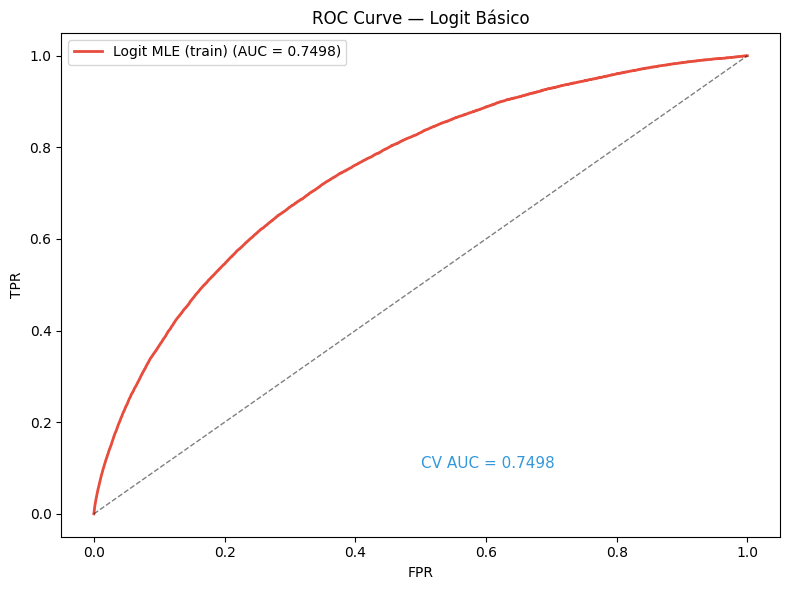

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_roc_curve(y, y_prob_train, label='Logit MLE (train)',
               color='#e74c3c', ax=ax, title='ROC Curve — Logit Básico')
ax.annotate(f'CV AUC = {cv_mean:.4f}', xy=(0.5, 0.1),
            fontsize=11, color='#3498db')
plt.tight_layout()
plt.show()


## 5. Coeficientes (Top 20 por |z|)

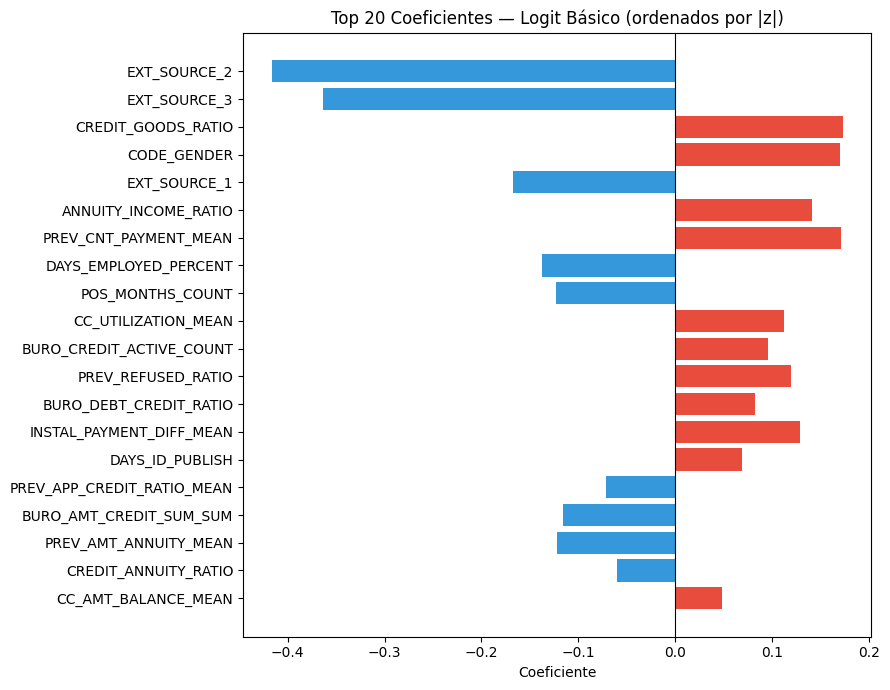

In [11]:
coef_df = pd.DataFrame({
    'Feature'  : cols_with_const,
    'Coef'     : result.params,
    'pvalue'   : result.pvalues,
    'z'        : result.tvalues
}).set_index('Feature')

# Excluir const, ordenar por |z|
coef_plot = coef_df.drop('const').reindex(
    coef_df.drop('const')['z'].abs().sort_values(ascending=False).index
).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coef_plot['Coef']]
ax.barh(coef_plot.index[::-1], coef_plot['Coef'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente')
ax.set_title('Top 20 Coeficientes — Logit Básico (ordenados por |z|)')
plt.tight_layout()
plt.show()


In [12]:
# Tabla completa de coeficientes con significancia
coef_df['Signif'] = coef_df['pvalue'].apply(
    lambda p: '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else '')))
display(coef_df.drop('const').sort_values('z', key=abs, ascending=False))

,Coef,pvalue,z,Signif
Feature,,,,
EXT_SOURCE_2,-0.416414,0.000000e+00,-64.802071,***
EXT_SOURCE_3,-0.363348,0.000000e+00,-46.686787,***
CREDIT_GOODS_RATIO,0.172771,2.715597e-155,26.547901,***
CODE_GENDER,0.169967,8.750862e-132,24.427399,***
EXT_SOURCE_1,-0.167784,1.283393e-112,-22.552004,***
ANNUITY_INCOME_RATIO,0.140751,3.173250e-92,20.368647,***
PREV_CNT_PAYMENT_MEAN,0.170704,3.470888e-73,18.095294,***
DAYS_EMPLOYED_PERCENT,-0.137885,5.525782e-64,-16.887875,***
POS_MONTHS_COUNT,-0.122997,5.205678e-50,-14.869427,***


## 6. Predicciones sobre Test

In [13]:
X_test_const = sm.add_constant(X_test_scaled, has_constant='add')
y_test_prob  = result.predict(X_test_const)

submission = pd.DataFrame({'SK_ID_CURR': sk_ids_test, 'TARGET': y_test_prob})
out_path = DATA_DIR / 'submission_06_logit.csv'
submission.to_csv(out_path, index=False)

print(f'Predicciones guardadas en: {out_path}')
print(f'Shape: {submission.shape}')
print(f'Score medio predicho: {y_test_prob.mean():.4f}')
display(submission.head())

Predicciones guardadas en: ..\..\data\processed\submission_06_logit.csv
Shape: (48744, 2)
Score medio predicho: 0.0819


,SK_ID_CURR,TARGET
0,100001,0.057193
1,100005,0.161722
2,100013,0.039313
3,100028,0.032184
4,100038,0.114370


## Resumen Final

In [14]:
print('=' * 60)
print('LOGIT BÁSICO (statsmodels) — RESUMEN')
print('=' * 60)
for k, v in metrics.items():
    if k != 'Model':
        print(f'  {k:<12}: {v}')
print(f'  {"CV_AUC":<12}: {cv_mean:.4f} ± {cv_std:.4f}')
print('=' * 60)

LOGIT BÁSICO (statsmodels) — RESUMEN
  AUC         : 0.7498
  N           : 307511
  P           : 866
  TP          : 453
  TN          : 282273
  FP          : 413
  FN          : 24372
  Recall      : 0.0182
  Precision   : 0.5231
  F1          : 0.0353
  CV_AUC      : 0.7498 ± 0.0053


## Kaggle Submission — AUC Test (Public Leaderboard)

Envía el CSV a `home-credit-default-risk` y recupera el AUC del Public LB (~30% del test).
Usa la Python API (`KaggleApi`) directamente — polling cada 10 s, máx 5 min.

> **Límite**: 5 submissions/día.


In [15]:
from kaggle import KaggleApi
import time

COMPETITION = 'home-credit-default-risk'
_sub_path   = DATA_DIR / 'submission_06_logit.csv'
_msg = f"06_logit_mle | train={metrics["AUC"]:.4f} | CV={cv_mean:.4f}"

def _as_str(x):
    return '' if x is None else str(x)

def _get_score(api, comp, file_name, message, poll=10, timeout=300):
    """Poll until public_score appears on the matching submission."""
    start = time.time()
    while time.time() - start < timeout:
        subs = api.competition_submissions(comp)
        matched = next(
            (s for s in subs
             if _as_str(getattr(s, 'file_name', None)) == file_name
             and _as_str(getattr(s, 'description', None)) == message),
            subs[0] if subs else None
        )
        if matched:
            pub     = _as_str(getattr(matched, 'public_score',  None))
            status  = _as_str(getattr(matched, 'status',        None))
            elapsed = int(time.time() - start)
            print(f'  [{elapsed:>3}s] status={status!r}  public_score={pub!r}')
            if pub and pub.lower() not in ('', 'none', 'null', '-'):
                priv = _as_str(getattr(matched, 'private_score', None))
                return float(pub), (float(priv) if priv and priv.lower() not in ('','none','null','-') else None)
        time.sleep(poll)
    return None, None

_api = KaggleApi()
_api.authenticate()

print(f'Enviando: {_msg}')
_api.competition_submit(file_name=str(_sub_path), message=_msg, competition=COMPETITION)
print('Esperando scoring (poll 10 s / máx 5 min)...')

public_auc, private_auc = _get_score(_api, COMPETITION, _sub_path.name, _msg)
print(f'\nAUC test  Public  LB : {public_auc}')
print(f'AUC test  Private LB : {private_auc}')


Enviando: 06_logit_mle | train=0.7498 | CV=0.7498


100%|██████████| 1.31M/1.31M [00:01<00:00, 828kB/s] 


Esperando scoring (poll 10 s / máx 5 min)...
  [  0s] status='SubmissionStatus.PENDING'  public_score=''
  [ 10s] status='SubmissionStatus.COMPLETE'  public_score='0.74978'

AUC test  Public  LB : 0.74978
AUC test  Private LB : 0.73499
